Train data shape: (13903, 17)
Test data shape: (3476, 17)
Root Mean Squared Error on test set: 153.37985334739258
Mean Absolute Error on test set: 115.05746726277184
R^2 on test set: 0.257063830218348


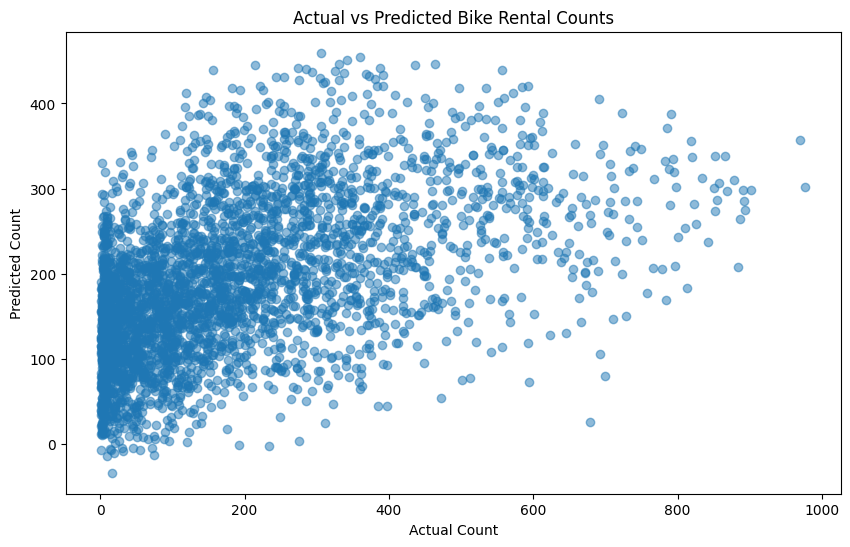

In [18]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Load the dataset
hourly_bike = pd.read_csv('../data/hour.csv')

# standardize the data
scaler = StandardScaler()
hourly_bike[['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'weekday', 'weathersit']] = scaler.fit_transform(hourly_bike[['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'weekday', 'weathersit']])

# train/test split
train_data, test_data = train_test_split(hourly_bike, test_size=0.2, random_state=42)
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Fit a simple linear regression model
model = LinearRegression(fit_intercept=True)
X_train = train_data[['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'weekday', 'weathersit']]
y_train = train_data['cnt']
X_test = test_data[['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'weekday', 'weathersit']]
y_test = test_data['cnt']
feature_names = X_train.columns.tolist()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
coef_series = pd.Series(
  data=model.coef_,
  index=feature_names
)

# Evaluate the model
y_pred = model.predict(X_test_scaled)

# calculate RMSE
lr_rmse = root_mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error on test set: {lr_rmse}")

# calculate MAE
lr_mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error on test set: {lr_mae}")

# calculate R^2
lr_r2 = model.score(X_test_scaled, y_test)
print(f"R^2 on test set: {lr_r2}")

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted Bike Rental Counts')
plt.show()

=== Model with Sinusoidal and Polynomial Features ===
Mean Squared Error: 8209.71
Root Mean Squared Error: 90.61
Mean Absolute Error: 63.97
R² Score: 0.7407

=== Baseline Model (No Temporal or Polynomial Features) ===
R² Score: 0.2571
Improvement: 0.4837


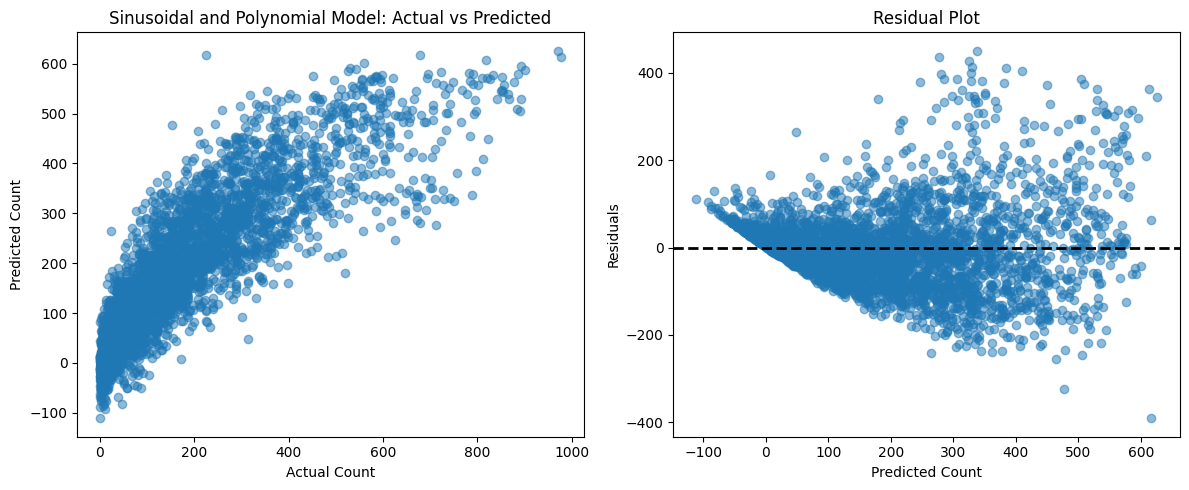

In [2]:
# Create sinusoidal features for time of day and month
train_data_copy = train_data.copy()
test_data_copy = test_data.copy()

# Convert dteday to datetime if not already
train_data_copy['dteday'] = pd.to_datetime(train_data_copy['dteday'])
test_data_copy['dteday'] = pd.to_datetime(test_data_copy['dteday'])

# Create sinusoidal features for hour of day (0-23)
train_data_copy['hour_sin'] = np.sin(2 * np.pi * train_data_copy['hr'] / 24)
train_data_copy['hour_cos'] = np.cos(2 * np.pi * train_data_copy['hr'] / 24)
test_data_copy['hour_sin'] = np.sin(2 * np.pi * test_data_copy['hr'] / 24)
test_data_copy['hour_cos'] = np.cos(2 * np.pi * test_data_copy['hr'] / 24)

# Create sinusoidal features for month (1-12), offset by 1
train_data_copy['month_sin'] = np.sin(2 * np.pi * (train_data_copy['mnth'] - 1) / 12)
train_data_copy['month_cos'] = np.cos(2 * np.pi * (train_data_copy['mnth'] - 1) / 12)
test_data_copy['month_sin'] = np.sin(2 * np.pi * (test_data_copy['mnth'] - 1) / 12)
test_data_copy['month_cos'] = np.cos(2 * np.pi * (test_data_copy['mnth'] - 1) / 12)

# Fit linear regression model with sinusoidal features
model_sinusoidal = LinearRegression()
X_train_sin = train_data_copy[['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'weekday', 'weathersit', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']]
y_train_sin = train_data_copy['cnt']

X_test_sin = test_data_copy[['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'weekday', 'weathersit', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']]
y_test_sin = test_data_copy['cnt']

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sin)
X_test_scaled = scaler.transform(X_test_sin)

# add polynomial features
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Fit the model
model_sinusoidal.fit(X_train_poly, y_train_sin)

# Evaluate on test set
y_pred_sin = model_sinusoidal.predict(X_test_poly)

# Calculate metrics
mse_sin = ((y_test_sin - y_pred_sin) ** 2).mean()
rmse_sin = np.sqrt(mse_sin)
mae_sin = mean_absolute_error(y_test_sin, y_pred_sin)
r2_sin = r2_score(y_test_sin, y_pred_sin)

print("=== Model with Sinusoidal and Polynomial Features ===")
print(f"Mean Squared Error: {mse_sin:.2f}")
print(f"Root Mean Squared Error: {rmse_sin:.2f}")
print(f"Mean Absolute Error: {mae_sin:.2f}")
print(f"R² Score: {r2_sin:.4f}")

model_results = [{'Model': 'Linear Regression (sin+poly)', 'RMSE': rmse_sin, 'MAE': mae_sin, 'R²': r2_sin}]

# Compare with baseline model
r2_baseline = r2_score(y_test, y_pred)
print(f"\n=== Baseline Model (No Temporal or Polynomial Features) ===")
print(f"R² Score: {r2_baseline:.4f}")
print(f"Improvement: {(r2_sin - r2_baseline):.4f}")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_sin, y_pred_sin, alpha=0.5, label='With Sinusoidal and Polynomial Features')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Sinusoidal and Polynomial Model: Actual vs Predicted')

plt.subplot(1, 2, 2)
residuals = y_test_sin - y_pred_sin
plt.scatter(y_pred_sin, residuals, alpha=0.5)
plt.axhline(y=0, color='k', linestyle='--', lw=2)
plt.xlabel('Predicted Count')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()


Create comparison table

📊 MODEL COMPARISON:
                       Model       RMSE        MAE       R²
               Lasso (α=0.1)  90.385409  63.814183 0.742005
              Ridge (α=10.0)  90.525734  63.909343 0.741203
               Ridge (α=1.0)  90.596337  63.962193 0.740799
               Ridge (α=0.1)  90.606310  63.969145 0.740742
Linear Regression (sin+poly)  90.607468  63.969939 0.740736
               Lasso (α=1.0)  91.679555  64.223806 0.734564
              Lasso (α=10.0) 104.404205  73.952131 0.655768
Linear Regression (baseline) 153.379853 115.057467 0.257064

Visualize model comparison


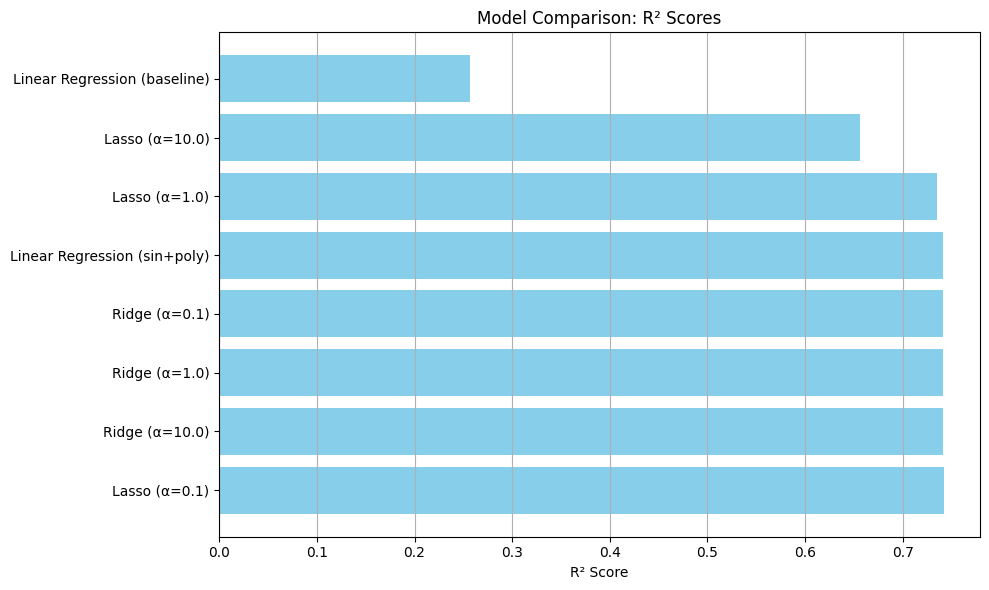

In [3]:

ridge_alphas = [0.1, 1.0, 10.0]
ridge_results = []

for alpha in ridge_alphas:
   ridge_regression = Ridge(alpha=alpha)
   ridge_regression.fit(X_train_poly, y_train_sin)
   ridge_pred = ridge_regression.predict(X_test_poly)
   ridge_rmse = root_mean_squared_error(y_test_sin, ridge_pred)
   ridge_mae = mean_absolute_error(y_test_sin, ridge_pred)
   ridge_r2 = r2_score(y_test_sin, ridge_pred)
   ridge_results.append({'Model': f'Ridge (α={alpha})', 'RMSE': ridge_rmse, 'MAE': ridge_mae, 'R²': ridge_r2})

lasso_alphas = [0.1, 1.0, 10.0]
lasso_results = []

# Note: Use max_iter=10000 for Lasso to ensure convergence
for alpha in lasso_alphas:
    lasso_regression = Lasso(alpha=alpha, max_iter=10000)
    lasso_regression.fit(X_train_poly, y_train_sin)
    lasso_pred = lasso_regression.predict(X_test_poly)
    lasso_rmse = root_mean_squared_error(y_test_sin, lasso_pred)
    lasso_mae = mean_absolute_error(y_test_sin, lasso_pred)
    lasso_r2 = r2_score(y_test_sin, lasso_pred)
    lasso_results.append({'Model': f'Lasso (α={alpha})', 'RMSE': lasso_rmse, 'MAE': lasso_mae, 'R²': lasso_r2})

print("\nCreate comparison table")

# Combine all results
all_results = [{'Model': 'Linear Regression (baseline)', 'RMSE': lr_rmse, 'MAE': lr_mae, 'R²': lr_r2}] + ridge_results + lasso_results + model_results  # Combine Linear, Ridge, Lasso, and Sinusoidal+Polynomial results

# Create DataFrame and sort by R²
results_df = pd.DataFrame(all_results).sort_values('R²', ascending=False)

print("\n📊 MODEL COMPARISON:")
if results_df is not None:
    print(results_df.to_string(index=False))

print("\nVisualize model comparison")

plt.figure(figsize=(10, 6))
plt.barh(range(len(results_df)), results_df['R²'], color='skyblue')
plt.yticks(range(len(results_df)), results_df['Model'])
plt.xlabel('R² Score')
plt.title('Model Comparison: R² Scores')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


📊 Feature Importance (Top 5):
                     Feature  Coefficient  Abs_Coefficient
           hour_sin hour_cos   -51.757030        51.757030
      temp holiday month_cos    43.542458        43.542458
         hour_sin^2 hour_cos   -42.691618        42.691618
workingday hour_sin hour_cos   -36.549630        36.549630
       workingday hour_cos^2   -30.596145        30.596145


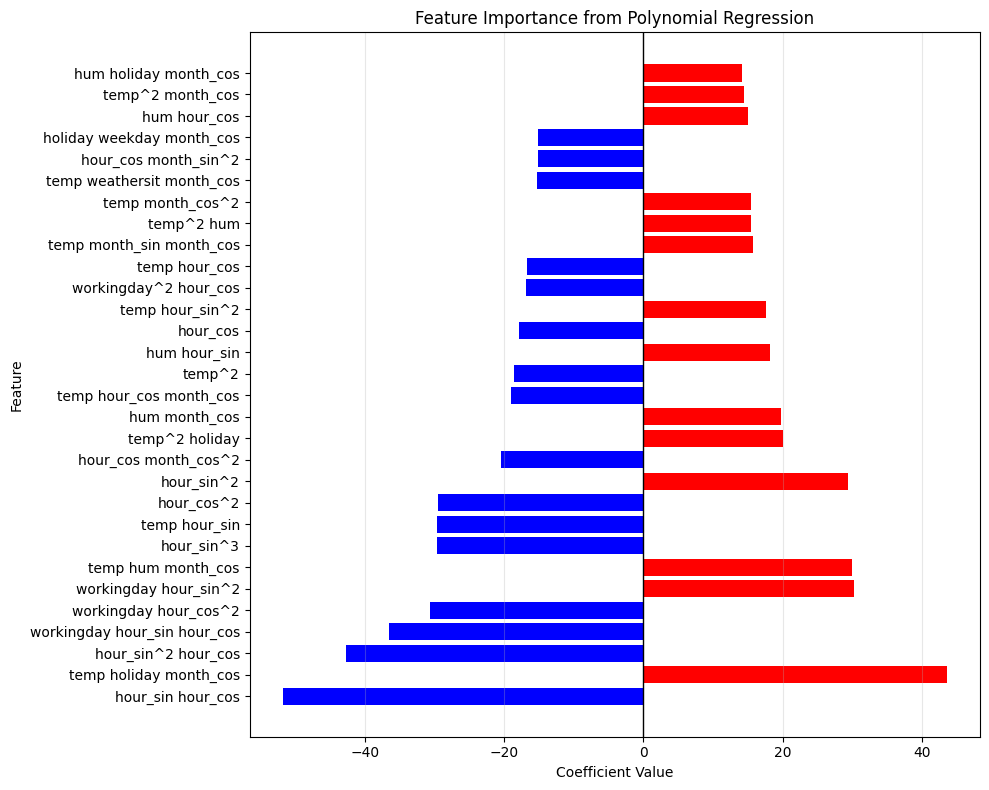

In [ ]:
# Get feature names after polynomial transformation
feature_names_poly = poly.get_feature_names_out(['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'weekday', 'weathersit', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'])

# Create DataFrame with features and coefficients from poly_model
feature_importance = pd.DataFrame({
    'Feature': feature_names_poly,
    'Coefficient': model_sinusoidal.coef_
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)


print("\n📊 Feature Importance (Top 5):")
if feature_importance is not None:
    print(feature_importance.head().to_string(index=False))

feature_importance = feature_importance[:30]

plt.figure(figsize=(10, 8))
# Create horizontal bar chart
# Use different colors for positive (red) vs negative (blue) coefficients
colors = ['red' if c > 0 else 'blue' for c in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance from Polynomial Regression (Top 30 features)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


📊 Feature Importance (Top 5):
 Coefficient    Feature  Abs_Coefficient
   69.651887       temp        69.651887
  -54.766068        hum        54.766068
   -4.123871    holiday         4.123871
    3.517838 weathersit         3.517838
    2.740104    weekday         2.740104


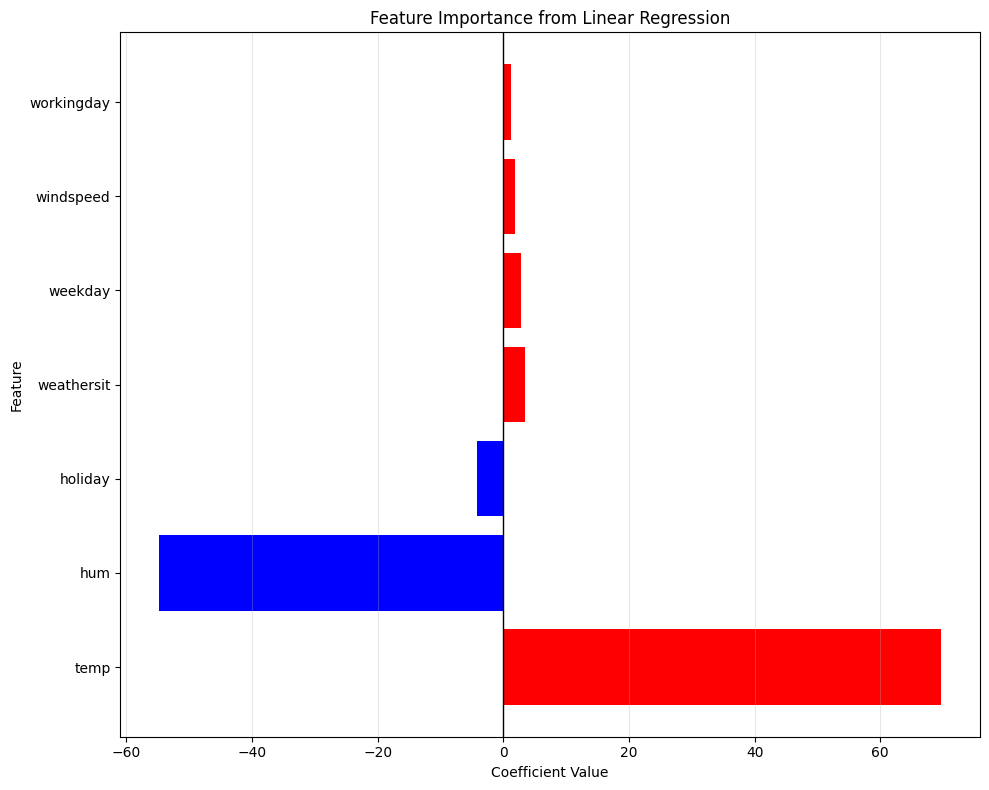

In [20]:
feature_importance = coef_series.to_frame(name='Coefficient')
feature_importance['Feature'] = feature_importance.index

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)


print("\n📊 Feature Importance (Top 5):")
if feature_importance is not None:
    print(feature_importance.head().to_string(index=False))

feature_importance = feature_importance[:30]

plt.figure(figsize=(10, 8))
# Create horizontal bar chart
# Use different colors for positive (red) vs negative (blue) coefficients
colors = ['red' if c > 0 else 'blue' for c in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance from Linear Regression')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()